
# Bike Sharing Demand Analysis
## DSI Cohort 8 – Infrastructure & Transportation

This notebook follows the task described in the dataset README:
**Regression modeling to predict bike rental demand (`cnt`).**

We demonstrate two regression models:
- Linear Regression (baseline)
- Random Forest Regression

Alongside two advanced visualizations:
1. Demand Heatmap (Hour × Day of Week)
2. Seasonal Rental Distribution (Box Plot)


## 1. Load Libraries and Dataset

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

hour = pd.read_csv("hour_clean (1).csv")
hour.head()


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,cnt,season_label,weather_label,year_label,day_type_label,temp_celsius,humidity_pct,windspeed_kmh
0,1,1,0,1,0,0,6,0,1,0.24,...,0.81,0.0,16,Winter,Clear,2011,Weekend/Holiday,9.8,81.0,0.0
1,2,1,0,1,1,0,6,0,1,0.22,...,0.80,0.0,40,Winter,Clear,2011,Weekend/Holiday,9.0,80.0,0.0
2,3,1,0,1,2,0,6,0,1,0.22,...,0.80,0.0,32,Winter,Clear,2011,Weekend/Holiday,9.0,80.0,0.0
3,4,1,0,1,3,0,6,0,1,0.24,...,0.75,0.0,13,Winter,Clear,2011,Weekend/Holiday,9.8,75.0,0.0
4,5,1,0,1,4,0,6,0,1,0.24,...,0.75,0.0,1,Winter,Clear,2011,Weekend/Holiday,9.8,75.0,0.0



## 2. Visualization 1 — Demand Heatmap (Hour × Day of Week)

This visualization reveals **daily commuting patterns** and peak demand periods.


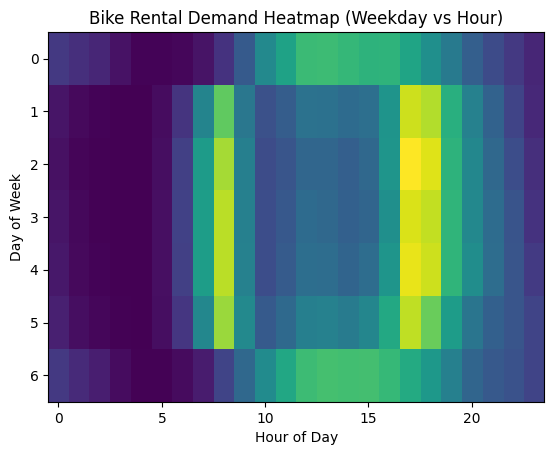

In [2]:

pivot = hour.pivot_table(values="cnt", index="weekday", columns="hr", aggfunc="mean")

plt.figure()
plt.imshow(pivot, aspect="auto")
plt.title("Bike Rental Demand Heatmap (Weekday vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()



## 3. Visualization 2 — Seasonal Rental Distribution (Box Plot)

This plot shows the **spread, median, and outliers** of bike rental demand across seasons.


<Figure size 640x480 with 0 Axes>

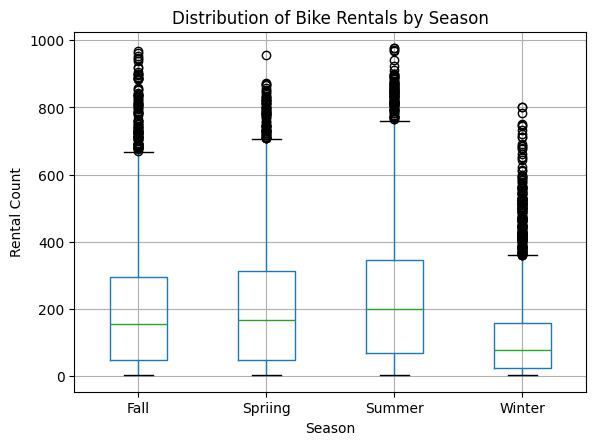

In [3]:

plt.figure()
hour.boxplot(column="cnt", by="season_label")
plt.title("Distribution of Bike Rentals by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Rental Count")
plt.show()



## 4. Prepare Data for Regression Models


In [4]:

features = [
"hr",
"workingday",
"temp_celsius",
"humidity_pct",
"windspeed_kmh"
]

X = hour[features]
y = hour["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## 5. Model 1 — Linear Regression (Baseline)


In [6]:

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_r2


0.3371103296566975


## 6. Model 2 — Random Forest Regression


In [9]:

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_r2


0.80686218961799


## 7. Model Comparison
Higher R² indicates better predictive performance.


In [8]:

print("Linear Regression R²:", lr_r2)
print("Random Forest R²:", rf_r2)


Linear Regression R²: 0.3371103296566975
Random Forest R²: 0.80686218961799
